### 라이브러리 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 데이터 읽기

In [ ]:
df = pd.read_csv('dataFile/medical.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,2.990000e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,5.590000e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4.260000e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,8.680000e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8.840000e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No


### 데이터 구조 파악

In [4]:
# 컬럼(열) 확인
df.columns.tolist()

['PatientId',
 'AppointmentID',
 'Gender',
 'ScheduledDay',
 'AppointmentDay',
 'Age',
 'Neighbourhood',
 'SMS_received',
 'No-show']

In [5]:
# 각 컬럼의 데이터 타입, 결측치 개수, 전체 행 수 한 번에 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   SMS_received    110527 non-null  int64  
 8   No-show         110527 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 7.6 MB


In [ ]:
# 결측치 파악
df.isnull()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
110522,False,False,False,False,False,False,False,False,False
110523,False,False,False,False,False,False,False,False,False
110524,False,False,False,False,False,False,False,False,False
110525,False,False,False,False,False,False,False,False,False


In [ ]:
# 컬럼별 결측치의 수
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
SMS_received      0
No-show           0
dtype: int64

In [ ]:
# 전체 데이터프레임의 결측치 수
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# 한 행에 결측치가 하나라도 있는지
df.isnull().any(axis=1)

0         False
1         False
2         False
3         False
4         False
          ...  
110522    False
110523    False
110524    False
110525    False
110526    False
Length: 110527, dtype: bool

In [ ]:
# 한 열에 결측치가 하나라도 있는지
df.isnull().any(axis=0)

PatientId         False
AppointmentID     False
Gender            False
ScheduledDay      False
AppointmentDay    False
Age               False
Neighbourhood     False
SMS_received      False
No-show           False
dtype: bool

In [ ]:
# 기초통계량 확인 : 개수, 평균, 표준편차, 최소, Q1, Q2, Q3, 최대
df.describe()   # 숫자형

,PatientId,AppointmentID,Age,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000
mean,1.474961e+14,5.675305e+06,37.088874,0.321026
std,2.560943e+14,7.129575e+04,23.110205,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000
25%,4.170000e+12,5.640286e+06,18.000000,0.000000
50%,3.170000e+13,5.680573e+06,37.000000,0.000000
75%,9.440000e+13,5.725524e+06,55.000000,1.000000
max,1.000000e+15,5.790484e+06,115.000000,1.000000


In [ ]:
df.describe(include='all')  # 숫자형 + 문자형

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
count,1.105270e+05,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527
unique,NaN,NaN,2,103549,27,NaN,81,NaN,2
top,NaN,NaN,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,NaN,JARDIM CAMBURI,NaN,No
freq,NaN,NaN,71840,24,4692,NaN,7717,NaN,88208
mean,1.474961e+14,5.675305e+06,NaN,NaN,NaN,37.088874,NaN,0.321026,NaN
std,2.560943e+14,7.129575e+04,NaN,NaN,NaN,23.110205,NaN,0.466873,NaN
min,3.920000e+04,5.030230e+06,NaN,NaN,NaN,-1.000000,NaN,0.000000,NaN
25%,4.170000e+12,5.640286e+06,NaN,NaN,NaN,18.000000,NaN,0.000000,NaN
50%,3.170000e+13,5.680573e+06,NaN,NaN,NaN,37.000000,NaN,0.000000,NaN
75%,9.440000e+13,5.725524e+06,NaN,NaN,NaN,55.000000,NaN,1.000000,NaN


In [ ]:
df.describe(include='str')  # 문자형

,Gender,ScheduledDay,AppointmentDay,Neighbourhood,No-show
count,110527,110527,110527,110527,110527
unique,2,103549,27,81,2
top,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI,No
freq,71840,24,4692,7717,88208


### 이상치 제거(Age)

In [15]:
# Age가 0 이상인 행만 남긴다 → 이상치 제거
df['Age'] >= 0

0         True
1         True
2         True
3         True
4         True
          ... 
110522    True
110523    True
110524    True
110525    True
110526    True
Name: Age, Length: 110527, dtype: bool

In [ ]:
# df['Age'] >= 0 조건이 참인 데이터만 출력
df[df['Age'] >= 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,2.990000e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,5.590000e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4.260000e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,8.680000e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8.840000e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,1,No
110523,3.600000e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,1,No
110524,1.560000e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,1,No
110525,9.210000e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,1,No


In [18]:
df = df[df.Age >= 0]
df.info()

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110526 non-null  float64
 1   AppointmentID   110526 non-null  int64  
 2   Gender          110526 non-null  str    
 3   ScheduledDay    110526 non-null  str    
 4   AppointmentDay  110526 non-null  str    
 5   Age             110526 non-null  int64  
 6   Neighbourhood   110526 non-null  str    
 7   SMS_received    110526 non-null  int64  
 8   No-show         110526 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 8.4 MB


In [20]:
df.describe()

,PatientId,AppointmentID,Age,SMS_received
count,1.105260e+05,1.105260e+05,110526.000000,110526.000000
mean,1.474932e+14,5.675304e+06,37.089219,0.321029
std,2.560937e+14,7.129544e+04,23.110026,0.466874
min,3.920000e+04,5.030230e+06,0.000000,0.000000
25%,4.170000e+12,5.640285e+06,18.000000,0.000000
50%,3.170000e+13,5.680572e+06,37.000000,0.000000
75%,9.440000e+13,5.725523e+06,55.000000,1.000000
max,1.000000e+15,5.790484e+06,115.000000,1.000000


In [21]:
# 노쇼 컬럼 확인
df['No-show']

0         No
1         No
2         No
3         No
4         No
          ..
110522    No
110523    No
110524    No
110525    No
110526    No
Name: No-show, Length: 110526, dtype: str

In [ ]:
# 값들의 개수(클래스 수)
df['No-show'].value_counts()

No-show
No     88207
Yes    22319
Name: count, dtype: int64

In [24]:
# 노쇼 컬럼 값 'Yes' / 'No' → 1 / 0
df['No-show'] = df['No-show'].map({'Yes':1, 'No':0})

In [25]:
df['No-show']

0         0
1         0
2         0
3         0
4         0
         ..
110522    0
110523    0
110524    0
110525    0
110526    0
Name: No-show, Length: 110526, dtype: int64

In [26]:
df['No-show'].value_counts()

No-show
0    88207
1    22319
Name: count, dtype: int64

In [27]:
# 문자 메시지 수신 여부
df['SMS_received'].value_counts()

SMS_received
0    75044
1    35482
Name: count, dtype: int64

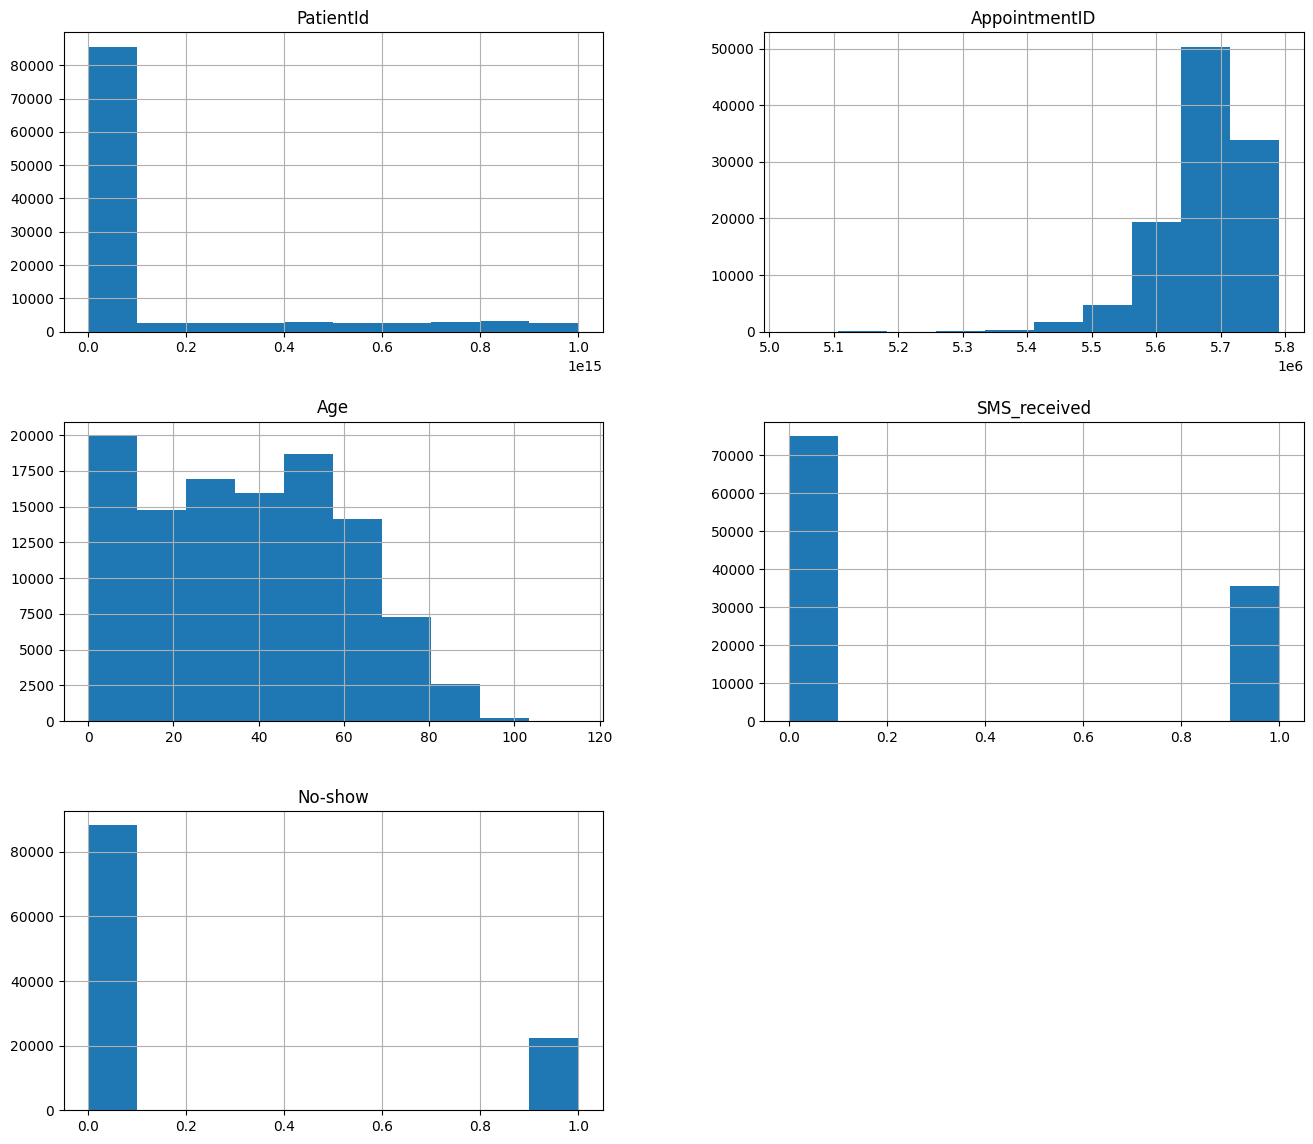

In [28]:
# 데이터프레임의 모든 숫자형 컬럼을 한 번에 히스토그램으로 전체적인 데이터 분포를 훑어보기
df.hist(figsize=(16, 14))
plt.show()

### 날짜 타입으로 형변환 & 대기일수(waiting_day) 컬럼 생성

In [29]:
# 날짜형으로 변경 → pd.to_datetime()
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])

df.info()

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  str                
 3   ScheduledDay    110526 non-null  datetime64[us, UTC]
 4   AppointmentDay  110526 non-null  datetime64[us, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  str                
 7   SMS_received    110526 non-null  int64              
 8   No-show         110526 non-null  int64              
dtypes: datetime64[us, UTC](2), float64(1), int64(4), str(2)
memory usage: 8.4 MB


In [30]:
# waiting_day = 병원 방문일의 연중 일수 - 예약한 날의 연중 일수
#   - 예약 후 실제 병원에 가기까지 며칠 기다렸는가
# dt.dayofyear : 1월 1일을 1로 시작해서 그 해의 몇 번째 날인지 숫자로 반환
df['waiting_day'] = df['AppointmentDay'].dt.dayofyear - df['ScheduledDay'].dt.dayofyear

df.info()

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  str                
 3   ScheduledDay    110526 non-null  datetime64[us, UTC]
 4   AppointmentDay  110526 non-null  datetime64[us, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  str                
 7   SMS_received    110526 non-null  int64              
 8   No-show         110526 non-null  int64              
 9   waiting_day     110526 non-null  int32              
dtypes: datetime64[us, UTC](2), float64(1), int32(1), int64(4), str(2)
memory usage: 8.9 MB


In [31]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
0,2.990000e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,0,0
1,5.590000e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
2,4.260000e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0
3,8.680000e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0
4,8.840000e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0


### 이상치 제거(waiting_day)

In [32]:
# waiting_day가 음수인 것은 논리적 오류
# → 0 이상인 데이터만 남겨서 이상치를 제거
df = df[df['waiting_day'] >= 0]
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
0,2.990000e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,0,0
1,5.590000e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
2,4.260000e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0
3,8.680000e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0
4,8.840000e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
...,...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,1,0,35
110523,3.600000e+12,5650093,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,1,0,35
110524,1.560000e+13,5630692,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,1,0,41
110525,9.210000e+13,5630323,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,1,0,41


In [33]:
# 이상치가 잘 삭제되었는지 최소값으로 확인
df['waiting_day'].min()

np.int32(0)

### Age 컬럼의 이상치 재확인 & 제거

In [ ]:
# Age의 고유값 확인
df['Age'].unique()

array([ 62,  56,   8,  76,  23,  39,  21,  19,  30,  29,  22,  28,  54,
        15,  50,  40,  46,   4,  13,  65,  45,  51,  32,  12,  61,  38,
        79,  18,  63,  64,  85,  59,  55,  71,  49,  78,  31,  58,  27,
         6,   2,  11,   7,   0,   3,   1,  69,  68,  60,  67,  36,  10,
        35,  20,  26,  34,  33,  16,  42,   5,  47,  17,  41,  44,  37,
        24,  66,  77,  81,  70,  53,  75,  73,  52,  74,  43,  89,  57,
        14,   9,  48,  83,  72,  25,  80,  87,  88,  84,  82,  90,  94,
        86,  91,  98,  92,  96,  93,  95,  97, 102, 115, 100,  99])

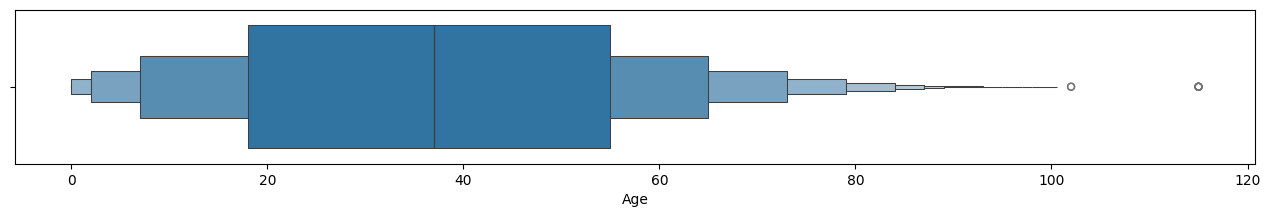

In [36]:
# boxplot으로 이상치 확인
plt.figure(figsize=(16, 2))
sns.boxenplot(x=df.Age)
plt.show()

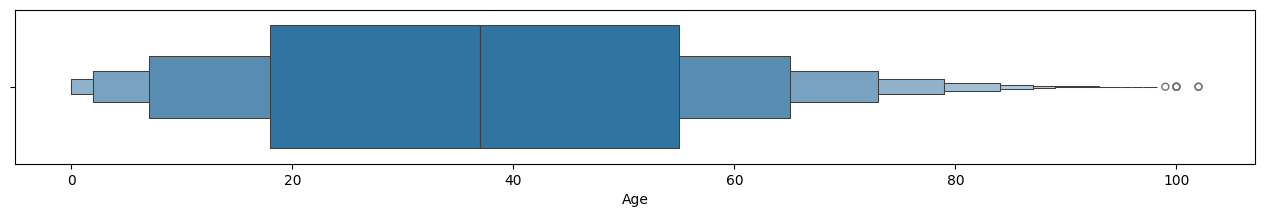

In [38]:
# 110세를 초과하는 나이는 비현실적이라고 판단해서 제거
df = df[df['Age'] <= 110]

plt.figure(figsize=(16, 2))
sns.boxenplot(x=df.Age)
plt.show()

### 당일 예약일 때 노쇼 비율

In [ ]:
# waiting_day == 0 → 노쇼 비율
#   waiting_day == 0(당일 예약)인 행들 중 'waiting_day' 값 개수 (=> 전체 당일 예약 건수)
a = df[df['waiting_day'] == 0]['waiting_day'].value_counts()
a

waiting_day
0    38561
Name: count, dtype: int64

In [42]:
# 앞 조건 + 노쇼가 발생한 건수('No-show' == 1)
#   waiting_day == 0
#   No-show == 1
cond = (df['waiting_day'] == 0) & (df['No-show'] == 1)
df[cond]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
145,2.370000e+13,5639602,M,2016-04-29 09:17:23+00:00,2016-04-29 00:00:00+00:00,17,ITARARÉ,0,1,0
212,4.270000e+14,5642059,M,2016-04-29 14:59:38+00:00,2016-04-29 00:00:00+00:00,62,SANTOS DUMONT,0,1,0
250,2.940000e+14,5640181,M,2016-04-29 10:13:35+00:00,2016-04-29 00:00:00+00:00,0,CARATOÍRA,0,1,0
251,6.540000e+11,5640178,F,2016-04-29 10:13:22+00:00,2016-04-29 00:00:00+00:00,33,CARATOÍRA,0,1,0
440,8.370000e+13,5639495,F,2016-04-29 09:09:55+00:00,2016-04-29 00:00:00+00:00,25,SÃO BENEDITO,0,1,0
...,...,...,...,...,...,...,...,...,...,...
109204,1.520000e+14,5770944,M,2016-06-03 11:11:18+00:00,2016-06-03 00:00:00+00:00,24,CONQUISTA,0,1,0
109603,7.520000e+13,5766961,F,2016-06-02 16:05:46+00:00,2016-06-02 00:00:00+00:00,42,JESUS DE NAZARETH,0,1,0
109856,1.230000e+11,5765114,F,2016-06-02 11:40:06+00:00,2016-06-02 00:00:00+00:00,69,JARDIM DA PENHA,0,1,0
109997,7.990000e+14,5771303,F,2016-06-03 12:17:04+00:00,2016-06-03 00:00:00+00:00,23,GRANDE VITÓRIA,0,1,0


In [ ]:
b = df[cond]['waiting_day'].value_counts()
b   # 당일예약 + 노쇼 수

waiting_day
0    1792
Name: count, dtype: int64

In [45]:
# b / a : 당일 예약 건수 중 노쇼가 발생한 비율
b / a

waiting_day
0    0.046472
Name: count, dtype: float64

### no-show / show 그룹 나눠서 waiting_day 분포 비교

In [46]:
# 노쇼인 데이터만 따로 모은 데이터프레임
no_show = df[df['No-show'] == 1]

In [47]:
# 정상 방문인 데이터만 따로 모은 데이터프레임
show = df[df['No-show'] == 0]

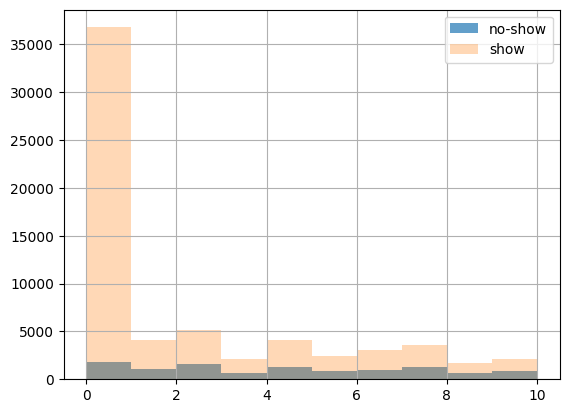

In [53]:
# waiting_day가 10일 이하인 구간만 잘라서, 노쇼/정상 방문의 분포 겹쳐서 비교
# alpha : 그래프의 투명도(0에 가까울수록 투명)
no_show[no_show['waiting_day'] <= 10]['waiting_day'].hist(alpha=0.7, label='no-show')
show[show['waiting_day'] <= 10]['waiting_day'].hist(alpha=0.3, label='show')
plt.legend()
plt.show()

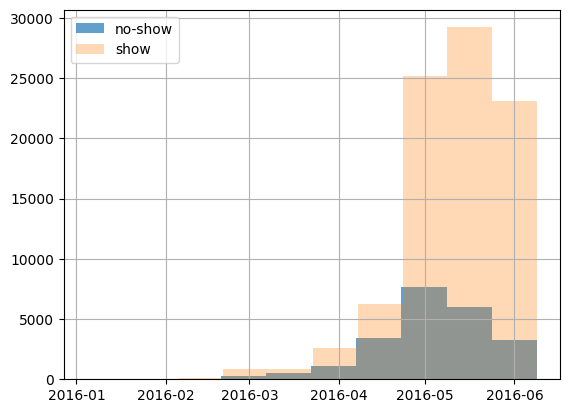

In [54]:
# 예약을 잡은 날짜(ScheduledDay) 기준으로 노쇼/정상 방문 분포 비교
no_show['ScheduledDay'].hist(alpha=0.7, label='no-show')
show['ScheduledDay'].hist(alpha=0.3, label='show')
plt.legend()
plt.show()

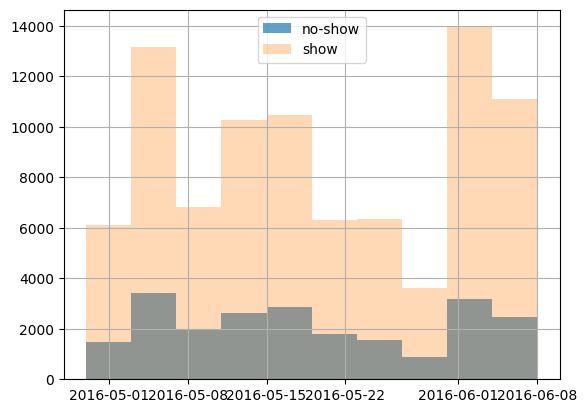

In [56]:
# 실제 병원 방문 예정일 기준으로 노쇼/정상 방문 비교 분포
no_show['AppointmentDay'].hist(alpha=0.7, label='no-show')
show['AppointmentDay'].hist(alpha=0.3, label='show')
plt.legend()
plt.show()

### 환자별 방문 횟수 분석 (재방문 환자)

In [58]:
# 환자id별로 몇 번 예약했는지 세어서, 예약 횟수가 많은 상위 10명 확인
df.PatientId.value_counts().iloc[:10]

PatientId
8.220000e+14    141
3.350000e+13    127
7.580000e+13    124
8.190000e+13    123
2.690000e+13    117
6.540000e+13    112
6.680000e+13    106
1.450000e+13    104
8.530000e+14    102
8.920000e+13    101
Name: count, dtype: int64

<Axes: >

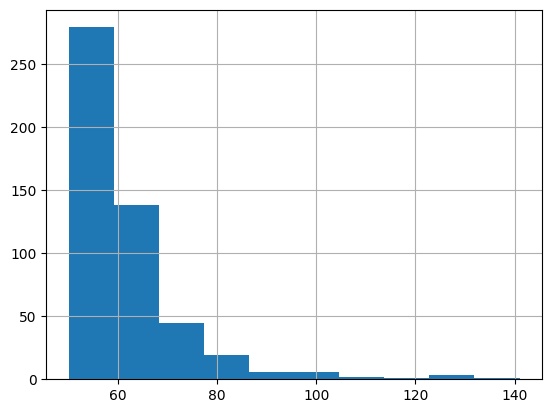

In [59]:
# 상위 500명 환자의 예약 횟수 히스토그램 (분포 파악 용도)
df.PatientId.value_counts().iloc[:500].hist()

In [60]:
df.PatientId.value_counts().iloc[:500]

PatientId
8.220000e+14    141
3.350000e+13    127
7.580000e+13    124
8.190000e+13    123
2.690000e+13    117
               ... 
1.490000e+13     50
6.470000e+13     50
2.620000e+12     50
5.240000e+12     50
7.270000e+13     50
Name: count, Length: 500, dtype: int64

상위 500명 환자의 예약 횟수 분포 확인 → 최소 50회 ~ 최대 141회
50번 ~ 60번 예약이 가장 많다
    → 500명의 환자들이 병원에 여러 번 재방문 해야 한다는 것을 의미

→ 환자별로 기다리는 기간에 따른 노쇼 발생 건수 파악

In [63]:
# waiting_day가 50 이상이면서 No-Show가 1인 환자 중 PatientID별 상위 건수 10명
#   → 오래 기다렸는데 노쇼한 환자가 누구인지, 반복적인지 확인하는 목적
df[(df['waiting_day'] >= 50) & (df['No-show'] == 1)].PatientId.value_counts().iloc[:10]

PatientId
3.380000e+14    6
7.250000e+13    4
7.850000e+13    4
8.340000e+12    4
8.220000e+14    3
4.970000e+12    3
9.150000e+14    3
5.670000e+12    3
8.460000e+12    3
5.290000e+12    3
Name: count, dtype: int64

### SMS_received와 waiting_day, No-show 관계

<Axes: xlabel='SMS_received', ylabel='waiting_day'>

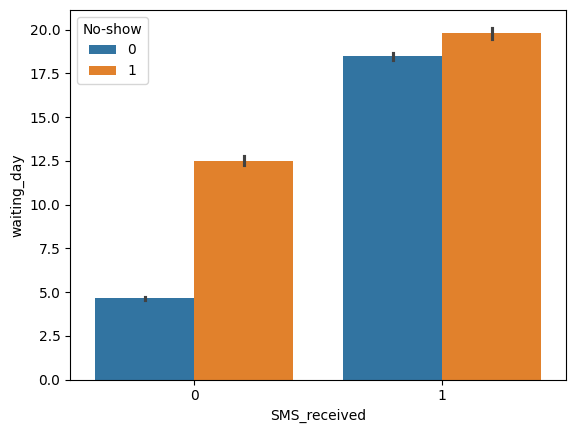

In [64]:
# sns.barplot() : x축별로 hue(색)을 나눠 y축의 평균을 막대로 비교
sns.barplot(data=df, x='SMS_received', y='waiting_day', hue='No-show')

In [70]:
# SMS_received가 0(문자 안 받음)일 때 노쇼 건수 a
a = len(df[(df['SMS_received'] == 0) & (df['No-show'] == 1)])

# SMS_received가 0(문자 안 받음)일 때 정상 방문 건수 b
b = len(df[(df['SMS_received'] == 0) & (df['No-show'] == 0)])

print(f'문자 안 받을 때 노쇼 : {a}건')
print(f'문자 안 받을 때 정상 방문 : {b}건')
print(f'문자 안 받을 때 노쇼 비율 : {a / (a + b):.2f}')

문자 안 받을 때 노쇼 : 12522건
문자 안 받을 때 정상 방문 : 62494건
문자 안 받을 때 노쇼 비율 : 0.17


In [69]:
# SMS_received가 1(문자 받음)일 때 노쇼 건수 c
c = len(df[(df['SMS_received'] == 1) & (df['No-show'] == 1)])

# SMS_received가 1(문자 받음)일 때 정상 방문 건수 d
d = len(df[(df['SMS_received'] == 1) & (df['No-show'] == 0)])

print(f'문자 받을 때 노쇼 : {c}건')
print(f'문자 받을 때 정상 방문 : {d}건')
print(f'문자 받을 때 노쇼 비율 : {c / (c + d):.2f}')

문자 받을 때 노쇼 : 9770건
문자 받을 때 정상 방문 : 25668건
문자 받을 때 노쇼 비율 : 0.28


In [71]:
# waiting_day, SMS_received, No-show 세 컬럼 간의 상관관계 계산
temp = df[['waiting_day', 'SMS_received', 'No-show']].corr()

<Axes: >

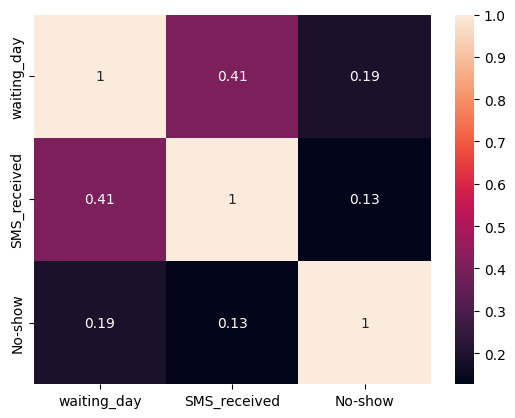

In [73]:
# 상관관계를 색상으로 표현한 히트맵 그래프
sns.heatmap(temp, annot=True)

### No-show와 성별 간의 관계

<Axes: xlabel='No-show', ylabel='count'>

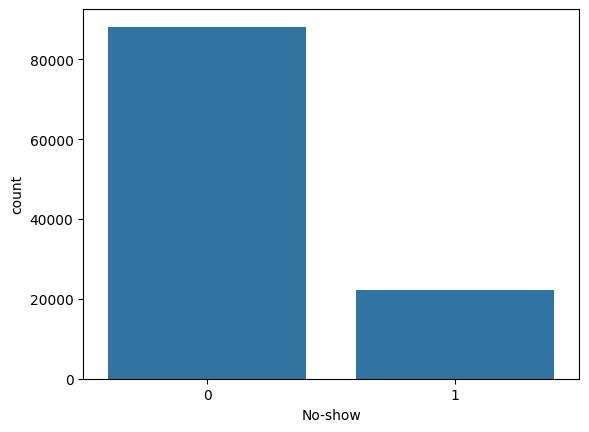

In [74]:
# 노쇼 컬럼의 전체 건수를 막대그래프로 시각화 → 전체 중 노쇼 비율 확인 용도
sns.countplot(df, x='No-show')

<Axes: xlabel='Gender', ylabel='count'>

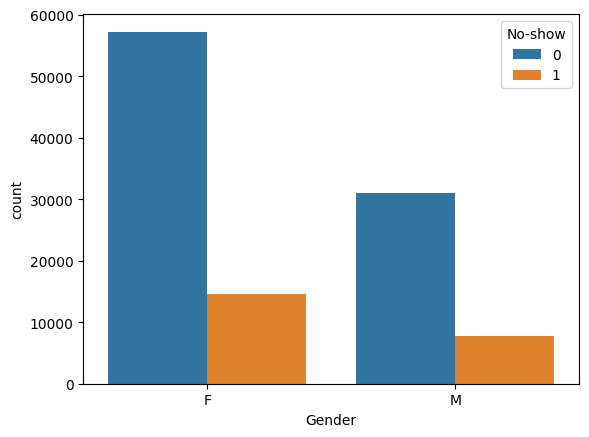

In [75]:
# 성별로 노쇼 건수를 색을 나눠 비교
sns.countplot(data=df, x='Gender', hue='No-show')

In [77]:
# 여성 중 No-show가 1인 인원수
여성인원수 = df[(df['Gender'] == 'F') & (df['No-show'] == 1)]['Gender'].value_counts()
여성인원수

Gender
F    14577
Name: count, dtype: int64

In [78]:
# 남성 중 No-show가 1인 인원수
남성인원수 = df[(df['Gender'] == 'M') & (df['No-show'] == 1)]['Gender'].value_counts()
남성인원수

Gender
M    7715
Name: count, dtype: int64

In [79]:
# 전체 여성 수
전체여성수 = df[df['Gender'] == 'F']['Gender'].value_counts()

# 전체 남성 수
전체남성수 = df[df['Gender'] == 'M']['Gender'].value_counts()

In [ ]:
print(여성인원수 / 전체여성수)
print(남성인원수 / 전체남성수)  # 결과가 비슷하다면 "성별은 노쇼에 크게 영향을 주지 않는다"라는 해석

Gender
F    0.203062
Name: count, dtype: float64
Gender
M    0.199519
Name: count, dtype: float64
